# Lab 0 — Setup Verification

<a class="btn btn-primary btn-sm" href="https://dhruvbalwada.github.io/intro-climate-modeling-fall2026/labs/verify_setup.ipynb" download>&#8681; Download this notebook (.ipynb)</a>

*Then upload it to [leap.2i2c.cloud](https://leap.2i2c.cloud/) and open it there.*

**Introduction to Climate Modeling · Fall 2026**

Run every cell in this notebook (`Shift+Enter`). If all cells run without errors and the plot at the end appears, your environment works. Then follow the Lab 0 instructions to put this notebook in your course GitHub repository.

*Fill in the next cell first.*

In [1]:
# EDIT THIS CELL
name = "YOUR NAME HERE"
uni = "YOUR UNI HERE"

print(f"Lab 0 submitted by {name} ({uni})")

Lab 0 submitted by YOUR NAME HERE (YOUR UNI HERE)


## 1. Check the scientific Python stack

These are the libraries we'll use all semester. This cell just confirms they import and prints their versions.

In [2]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import xarray as xr

print(f"python     {sys.version.split()[0]}")
print(f"numpy      {np.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"xarray     {xr.__version__}")
print("\nAll imports OK ✅")

python     3.11.15
numpy      2.4.6
matplotlib 3.10.9
xarray     2026.4.0

All imports OK ✅


## 2. A tiny computation — and a preview of Week 2

The **emission temperature** of a planet is the temperature it must radiate at to balance the sunlight it absorbs:

$$T_e = \left[\frac{S_0(1-\alpha)}{4\sigma}\right]^{1/4}$$

where $S_0$ is the solar constant, $\alpha$ the planetary albedo (how reflective the planet is), and $\sigma$ the Stefan–Boltzmann constant. Next week we'll derive this and discover why it gives the *wrong* answer for Earth's surface — in the most interesting way possible.

For now: run the cell and look at the plot.

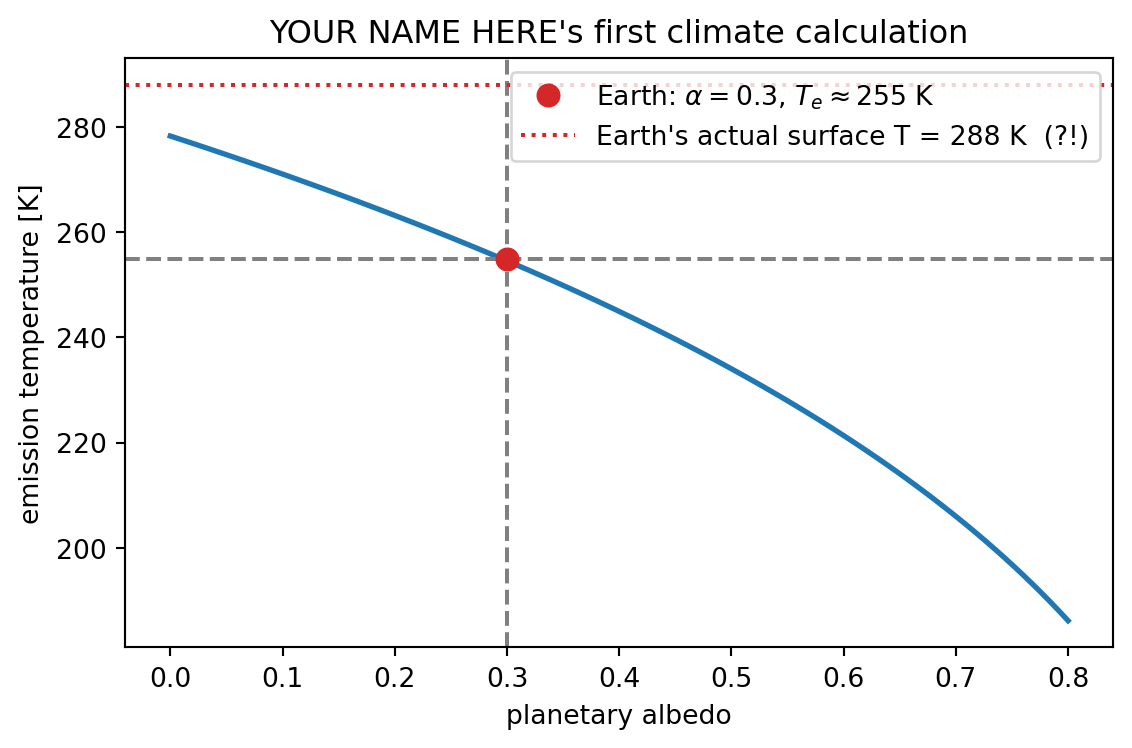

In [3]:
S0 = 1361.0      # solar constant [W m-2]
sigma = 5.67e-8  # Stefan-Boltzmann constant [W m-2 K-4]

albedo = np.linspace(0.0, 0.8, 100)
T_e = (S0 * (1 - albedo) / (4 * sigma)) ** 0.25

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(albedo, T_e, lw=2)
ax.axvline(0.3, ls="--", color="gray")
ax.axhline(255, ls="--", color="gray")
ax.plot(0.3, 255, "o", color="tab:red", ms=8, zorder=5,
        label="Earth: $\\alpha=0.3$, $T_e\\approx255$ K")
ax.axhline(288, ls=":", color="tab:red",
           label="Earth's actual surface T = 288 K  (?!)")
ax.set_xlabel("planetary albedo")
ax.set_ylabel("emission temperature [K]")
ax.set_title(f"{name}'s first climate calculation")
ax.legend()
fig.tight_layout()

That 33 K gap between the dashed gray line and the dotted red line? That's the greenhouse effect, and it's where this course begins.

## 3. Check xarray (our data workhorse)

Later in the course we'll use `xarray` to analyze output from real climate models. This cell just makes a tiny labeled dataset and takes a mean.

In [4]:
da = xr.DataArray(
    20 + 10 * np.random.randn(12, 4),
    dims=["month", "station"],
    coords={"month": np.arange(1, 13)},
    name="temperature",
    attrs={"units": "degC"},
)
print(da.mean(dim="station"))
print("\nxarray OK ✅")

<xarray.DataArray 'temperature' (month: 12)> Size: 96B
array([23.17888611, 23.26271069, 17.22814796, 20.15419686, 22.41996104,
       26.91842328, 12.48528426, 23.73935501, 20.32277205, 20.49307876,
       20.97235729, 22.81395741])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:    degC

xarray OK ✅


## Done!

If everything above ran cleanly:

1. Save this notebook (`Ctrl+S` / `Cmd+S`).
2. Follow **Part C** of the Lab 0 instructions to put it in your private course repo.
3. Follow **Part D** to post your repo link on Courseworks.

See you in class.